## **Predicting Customer Churn in SyriaTel Telecommunications**

In [1]:

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_curve, roc_auc_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay,roc_curve,roc_auc_score

import warnings
warnings.filterwarnings("ignore")

### 2. Business Understanding
In a competitive telecommunications industry customer churn is a big challenge that leads to significant financial losses to companies like SyriaTel.The main obective is to build a binary classifier to predict whether a customer will ("soon") stop doing business with SyriaTel. The ultimate goal is to help in reducing how much money is lost by the company as a result of customers who don't stick around very long by implementing proactive customer retention strategies by identifying patterns in customer behavior and demographic data that may indicate a likelihood that a customer will stop using SyriaTel services.

#### 2.1 Business Problem
### Business Problem

SyriaTel is experiencing customer churn, which leads to revenue loss and increased customer acquisition costs. The company currently lacks a way to identify customers who are likely to stop using its services. This project aims to develop a binary classification model that predicts whether a customer will churn.


#### 2.2 Project Objectives
#### 2.2.1 Main Objective
To develop the best model to predict customer churn for SyriaTel, aiming to reduce the financial impact of churn by implementing proactive retention strategies.

### 2.2.2 Specific Objectives
- Identify the customer features mostly associated with churn.

- Compare multiple classification models for churn prediction.

- Select the model that best supports the business goal of customer retention.

- Generate business recommendations based on model findings.


### 2.3 Success Measurement
The Project is termed successfull if:
- The model achieves strong recall on churned customers, so most at-risk customers are identified.

- The model maintains good precision, so the retention team does not waste resources targeting too many low-risk customers.

- The model achieves a competitive F1-score and ROC-AUC.

- The findings lead to practical business recommendation actions for improving customer retention.


### 2.3 Stakeholders

SyriaTel Management- use insights to support strategic decision-making and reduce customer loss

Customer retention team- use churn predictions to focus on retention efforts on customers most likely to leave.

Finance Department-revenue impact of churn and the return on investment of retention programmes

Marketing Team-use the findings to design promotions and improve customer engagement on the company platform


### 3. Data Understanding

#### 3.1 Data Source
The dataset used  was obtained from Kaggle and consists of 21 columns and 3333 rows. It contains information relevant to predicting customer churn for SyriaTel, a telecommunications company. Each row represents a customer, and each column represents a specific feature or attribute related to customer behavior, demographics, and interactions with SyriaTel's services.


### 4. Data Preparation

### 4.1  Load Dataset



In [2]:
#Load the churn dataset
df = pd.read_csv("bigml_59c28831336c6604c800002a.csv")

#Create a copy of the original dataframe to preserve the original data 
df_copy = df.copy()

#display the first few rows of the dataset to understand its structure and contents
df_copy.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


#### 4.2 Data Structure

In [3]:
#Display the summary information about the dataset, including data types and non-null counts

df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

In [4]:
#check for missing values in the dataset

df_copy.isnull().sum()

state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

Our dataset has a total of 3333 row and 21 columns with a clear indication of no missing values in the dataset

#### 4.3 Descriptive statistics

In [5]:
#Display summary statistics for the numerical columns

df_copy.describe()

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


### 5 Churn variable distribution

#### 5.1 Churn Distribution plot

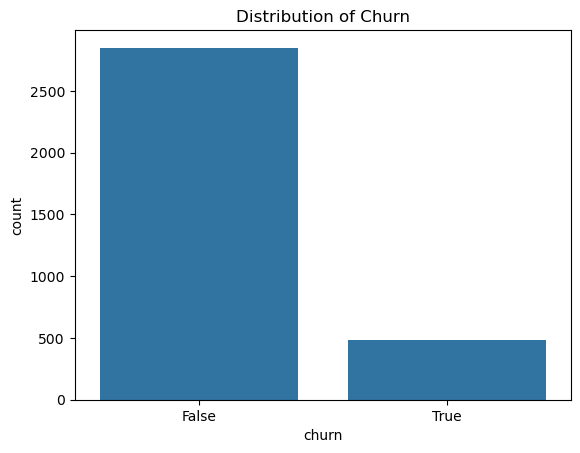

churn
False    2850
True      483
Name: count, dtype: int64


In [6]:
#Checking for class distribution in the target variable 'churn'
sns.countplot(x='churn', data=df_copy)
plt.title('Distribution of Churn')
plt.show()
print(df_copy['churn'].value_counts())

The target variable churn indicates that out of the reported 3333 customers,a total 2850(85.5%) customers did not stop using SyriaTel whereas a total 483(14.5%) customers stopped using SyriaTel. This indicates that the dataset is moderately imbalanced, with approximately 14.5% of customers stopped using the SyriaTel services.This will help in deciding the best metric to evaluate models.

#### 5.2 Customer Service Calls vs Churn

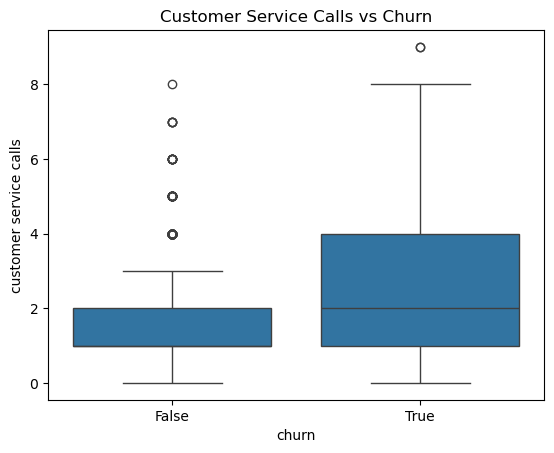

In [7]:
sns.boxplot(x='churn', y='customer service calls', data=df_copy)
plt.title("Customer Service Calls vs Churn")
plt.show()

Median Value: The median number of customer service calls for customers who churned (True) is higher (around 2) compared to those who stayed (False, around 1).
Interquartile Range (IQR): The middle 50% of churned customers generally make between 1 and 4 calls. For those who stayed, this range is tighter, mostly between 1 and 2 calls.
Outliers: Both groups have outliers  but the "False" group (non-churners) has a significant number of individuals making 4 to 8+ calls without leaving. This suggests that while high call volume is a risk factor, it doesn't guarantee a customer will leave.
Trend: There is a visible upward shift in the box for the "True" category. This indicates that as the number of customer service calls increases, the likelihood of churning also increases.

### 5.3 Histogram Plot Day Usage vs Churn

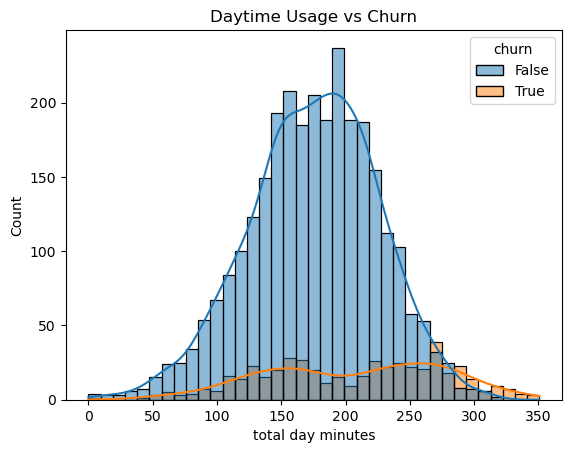

In [8]:
sns.histplot(data=df_copy, x='total day minutes', hue='churn', kde=True)
plt.title("Daytime Usage vs Churn")
plt.show()

The histogram suggests that customers with very high daytime usage tend to have a higher likelihood of churning as compared to customers with moderate or lower daytime usage.

#### 5.4 Correlation Heatmap

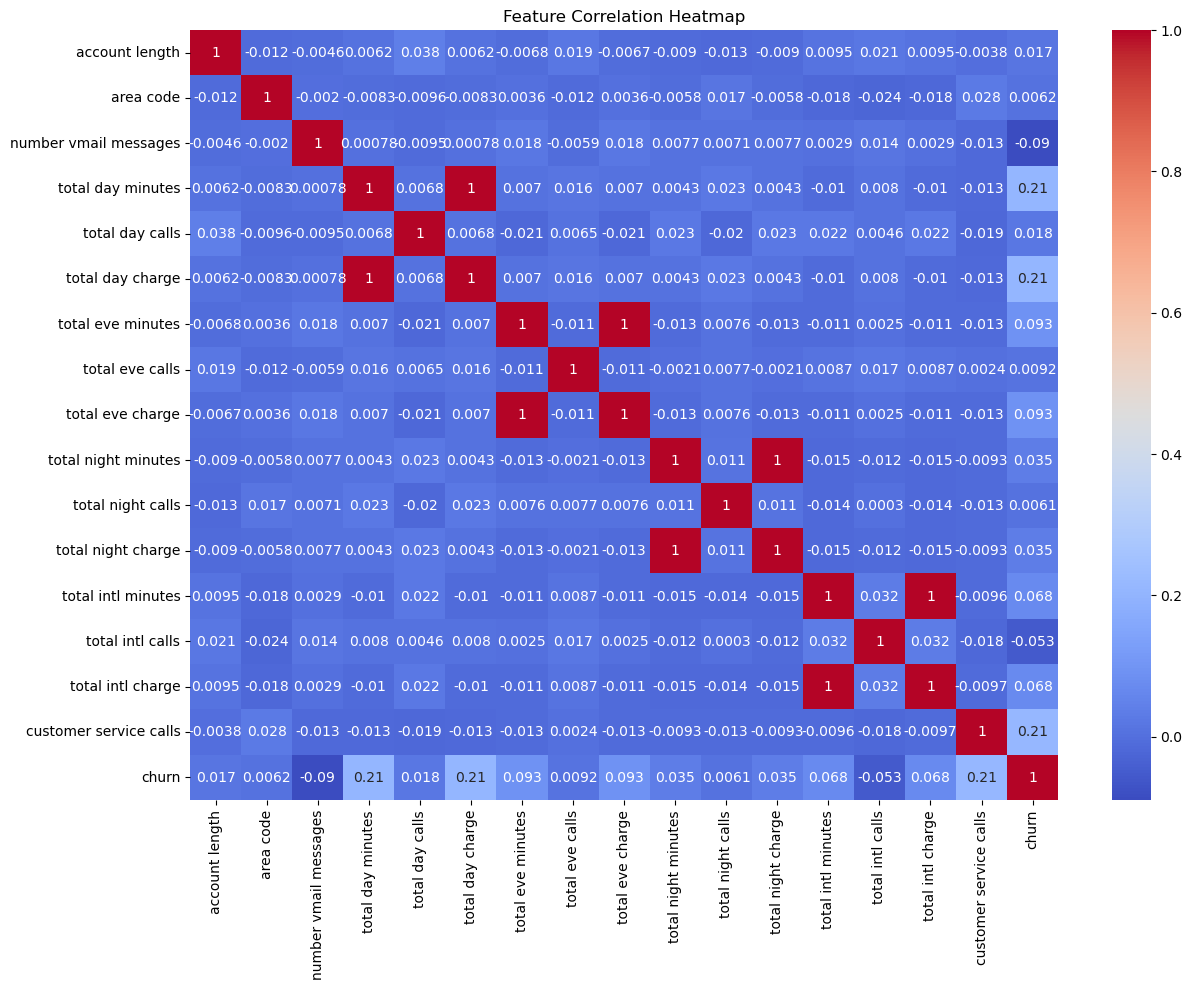

In [9]:
#conversion of target variable to int for correlation analysis
df_copy["churn"] = df_copy["churn"].astype(int)

#selecting only numerical feautures for correlation analysis
numeric_df = df_copy.select_dtypes(include=["int64","float64"])

#plot the correlation heatmap
plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(),annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

### Heatmap findings
##### 1.Strong multicollinearity
The features below show perfect correlation with each pairs having a value of 1
* Total day minutes and total day charge 
* Total eve minutes and total eve charge 
* Total night minutes and total night charge 
* Total intl minutes and total intl charge 

Keeping both pairs of variables would introduce redundancy and multicollinearity into the model.

#### 5.5 Churn based Heatmap
This heatmap focuses on the features that are most associated with churn

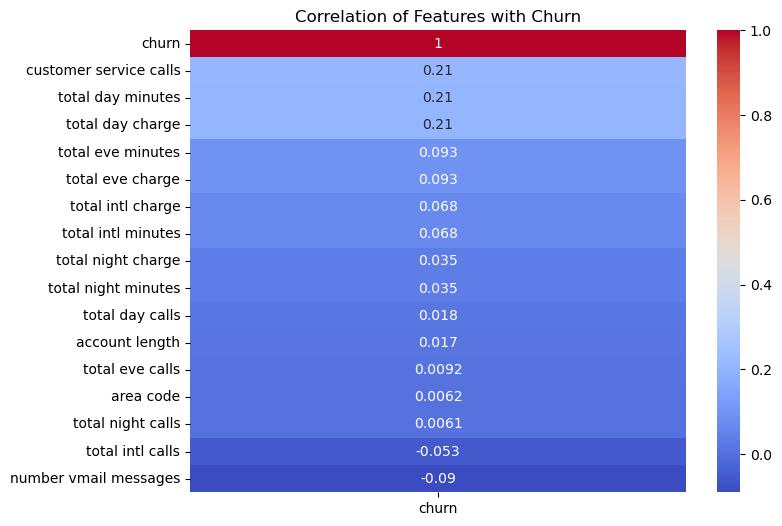

In [10]:
# Focus on churn correlations only
corr = numeric_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr[['churn']].sort_values(by='churn', ascending=False), annot=True, cmap='coolwarm')
plt.title("Correlation of Features with Churn")
plt.show()

### Churn Heatmap findings summary 
 #### 1.Top Predictors of Churn (Positive Correlation)
Customer service calls (0.21) - Strongest predictor

Total day minutes/charge (0.21) -Strong positive correlation

Total eve minutes/charge (0.093) - Moderate positive correlation

Total intl minutes/charge (0.068) - Weak positive correlation

The above correlations are useful in identifying influential features 
#### 2.Negative Correlators (Retention Factors)
Number vmail messages (-0.09) - Using voicemail reduces churn

total intl calls (-0.053) - Making international calls slightly reduces churn


### 6. Handling the Multicollinearity Features

The correlation analysis revealed that the charge variables are highly correlated with their corresponding usage-minute variables. Since the charges are directly derived from the minutes, they do not add new information to the model.

To reduce redundancy and simplify the model, the following columns were removed:
- total day charge
- total eve charge
- total night charge
- total intl charge

In [11]:
#dropping charge columns since they are directly derived from the minutes columns and would be redundant for modeling
df_copy = df_copy.drop(columns=[
    "total day charge",
    "total eve charge",
    "total night charge",
    "total intl charge"
])

### 7. Identify Target and Features 

In this section we drop phone number column from the dataset because it is a unique identifier and does not provide any meaningful predictive information about customer behavior.

The other columns are divided into features and target
- X: predictor variables
- y: target variable (churn)

In [12]:
# Drop phone number because it is an identifier, not a useful predictive feature
df_copy = df_copy.drop(columns=["phone number"])

# Separate features(X) and target(y)
X = df_copy.drop(columns=["churn"])
y = df_copy["churn"]

### 8 Train-Test Split 
In this section Split the data into training and testing sets
and use Stratify is  to preserve the churn class ratio in both sets

In [13]:
# Split the data into training and testing sets 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Total Training samples:", X_train.shape[0])
print("Total Testing samples:", X_test.shape[0])

Total Training samples: 2666
Total Testing samples: 667


The dataset was split into **80% training data** and **20% testing data**. Stratified sampling was used to preserve the class distribution of churn in test and train sets to ensure that the evaluation is fair and reflects the imbalance present in the original dataset.

### 9 .Feature Engineering
Feature engineering is used to create additional variables that  capture customer behavior.

In [14]:
class FeatureEngineering(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        X = X.copy()
#Total minutes across all calls periods
        X["total_minutes"] = (
            X["total day minutes"] +
            X["total eve minutes"] +
            X["total night minutes"] +
            X["total intl minutes"]
        )
#Total calls across all call periods
        X["total_calls"] = (
            X["total day calls"] +
            X["total eve calls"] +
            X["total night calls"] +
            X["total intl calls"]
        )
#Proportion of customer service calls to total calls
        X["service_call_rate"] = (
            X["customer service calls"] / X["total_calls"]
        )
#Total day minutes as a proportion of total minutes
        X["day_usage_ratio"] = (
            X["total day minutes"] / X["total_minutes"]
        )

        return X

New features created:
- **total_minutes**: total call minutes across day, evening, night, and international periods
- **total_calls**: total number of calls across all time periods
- **service_call_rate**: number of customer service calls relative to total calls
- **day_usage_ratio**: proportion of total usage that happens during the day


### 10. Preprocessing Pipeline

In this section data is preparedfor machine learning using using the techniques below

- Numerical values are scaled using  **StandardScaler**

- Categorical features are encoded using **OneHotEncoder**


In [15]:
#Define categorical features for preprocessing
categorical_features = [
    "state",
    "international plan",
    "voice mail plan"
]
#Apply feature engineering transformations to identified numerical features
X_train_feature = FeatureEngineering().fit_transform(X_train)

#Remaining columns are treated as numeric features and scaled
numeric_features = X_train_feature.drop(columns=categorical_features).columns

#Build preprocessing transformer for numeric and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ("numerical_scaling", StandardScaler(), numeric_features),
        ("categorical_encoding", OneHotEncoder(drop="first"), categorical_features)
    ]
)

### 11 .Reusable Evaluation function

In [16]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    #fit the model on the training data
    model.fit(X_train, y_train)

    #Predict on the test set and get probabilities for ROC curve
    predictions = model.predict(X_test)
    prob_predictions = model.predict_proba(X_test)[:, 1]

    #Print classification report 
    print(f"===== {model_name} =====")
    print("\nClassification Report")
    print(classification_report(y_test, predictions))

    #Compute and display confusion matrix
    cm = confusion_matrix(y_test, predictions)

    #Plot confusion matrix 
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    #Compute ROC curve and AUC score
    fpr, tpr, _ = roc_curve(y_test, prob_predictions)
    auc_score = roc_auc_score(y_test, prob_predictions)


    #Plot ROC curve
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
    plt.plot([0,1], [0,1], "--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} - ROC Curve")
    plt.legend()
    plt.show()

    print(f"{model_name} AUC Score: {auc_score:.3f}")
    
    #Return key evaluation metrics
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions),
        "ROC AUC": auc_score
    }

### 12. Baseline Model Logistic Regression
Logistic regression is used as a baseline model because we have a binary classification


===== Logistic Regression =====

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       570
           1       0.57      0.30      0.39        97

    accuracy                           0.87       667
   macro avg       0.73      0.63      0.66       667
weighted avg       0.84      0.87      0.85       667



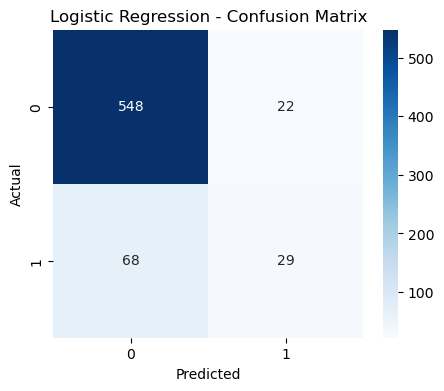

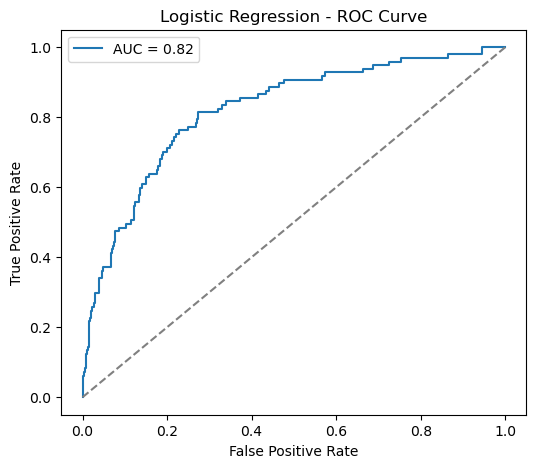

Logistic Regression AUC Score: 0.820


In [17]:
#Logistic Regression Pipeline
logistic_pipeline = Pipeline([
    ("features", FeatureEngineering()),
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, solver="liblinear"))
])

#Evaluate Logistic Regression model
logistic_results = evaluate_model(
    logistic_pipeline, X_train, X_test, y_train, y_test, "Logistic Regression"
)

#### Model Evaluation – Logistic Regression

#### Classification Report Interpretation

The logistic regression model achieved an **overall accuracy of 87%**. The model performs  well in identifying customers who will **not churn**, with a recall of **96%** for the non-churn customers.

The performance for predicting churn customers is weaker as it only detects **30%** of actual churn 
- **Precision:** 0.57
- **Recall:** 0.30
- **F1-score:** 0.39

#### Confusion Matrix Interpretation

- **True Negatives (548):** Customers correctly predicted as non-churn
- **False Positives (22):** Customers predicted to churn but actually stayed
- **False Negatives (68):** Customers who churned but were missed by the model
- **True Positives (29):** Customers correctly predicted to churn

#### ROC Curve and AUC

The ROC curve evaluates the model’s ability to distinguish between churn and non-churn customers across different classification thresholds.


#### Business Implications

The current model is effective at identifying customers who are likely to stay, but less effective at identifying those likely to churn.Improving churn detection is critical because retaining customers is generally more cost-effective than acquiring new ones.


### 13. Nonparametric Model: Decision Tree

===== Decision Tree =====

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       570
           1       0.70      0.68      0.69        97

    accuracy                           0.91       667
   macro avg       0.82      0.82      0.82       667
weighted avg       0.91      0.91      0.91       667



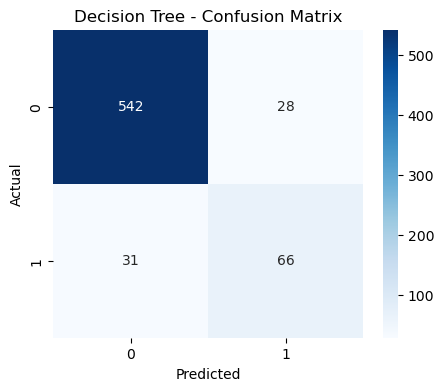

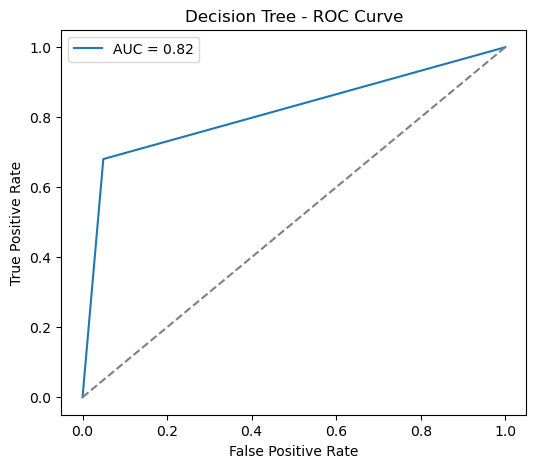

Decision Tree AUC Score: 0.816


In [18]:
tree_pipeline = Pipeline([
    ("features", FeatureEngineering()),
    ("preprocess", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])
tree_results = evaluate_model(
    tree_pipeline, X_train, X_test, y_train, y_test, "Decision Tree"
)

#### Decision Tree Model Evaluation

#### Classification Report Interpretation

The Decision Tree model achieved an **accuracy of 91%** performing better than logistic regression model. The model performs very well at identifying customers who will not churn, with a recall of **95%** for the non-churn class.

- **Precision:** 0.70
- **Recall:** 0.68
- **F1-score:** 0.69

This indicates that the model correctly identifies **68% of customers who churn**


### Confusion Matrix Interpretation

Predictions compared to actual customer outcomes.

- **True Negatives (542):** Customers correctly predicted to stay
- **False Positives (28):** Customers predicted to churn but stay
- **False Negatives (31):** Customers who churned but were missed
- **True Positives (66):** Customers correctly predicted to churn

The model successfully captures most churn customers and maintaining strong accuracy for non-churn predictions.

### Business Implications

The Decision Tree model provides a stronger value for churn prediction as it correctly identifies a larger proportion of customers likely to churn


### 14. Random Forest Ensemble

===== Random Forest =====

Classification Report
              precision    recall  f1-score   support

           0       0.91      1.00      0.95       570
           1       0.96      0.45      0.62        97

    accuracy                           0.92       667
   macro avg       0.94      0.73      0.78       667
weighted avg       0.92      0.92      0.90       667



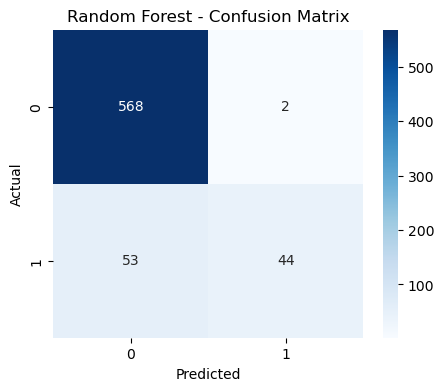

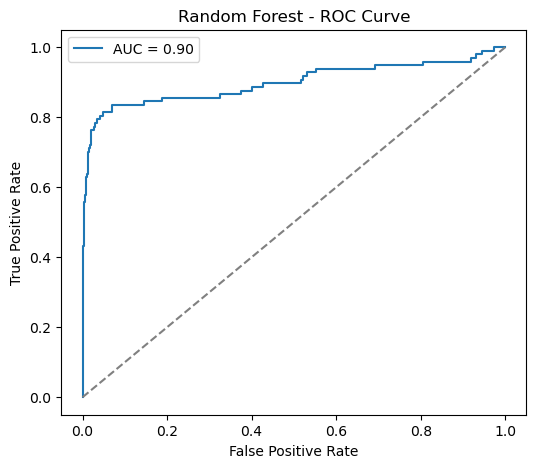

Random Forest AUC Score: 0.898


In [19]:
#Random Forest Pipeline
randomforest_pipeline = Pipeline([
    ("features", FeatureEngineering()),
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ))
])

#Evaluate Random Forest model
randomforest_results = evaluate_model(
    randomforest_pipeline, X_train, X_test, y_train, y_test, "Random Forest"
)

#### Random Forest Model Evaluation

#### Classification Report Interpretation

The Random Forest model achieved an overall **accuracy of 92%**,highest compared to other models. The model performs extremely well in identifying customers who will not churn with a recall of **100%**

For churn prediction, the model achieved:

- **Precision:** 0.96
- **Recall:** 0.45
- **F1-score:** 0.62

The high precision indicates that when the model predicts a customer will churn, it is correct most of the time. The recall of 45% indicates that the model  misses a significant number of churn customers.

### Confusion Matrix Interpretation

- **True Negatives (570):** Customers correctly predicted to stay
- **False Positives (0):** Loyal customers incorrectly predicted to churn
- **False Negatives (53):** Customers who churned but were missed
- **True Positives (44):** Customers correctly predicted to churn

The model does not falsely  predict churn but it misses some customers who actually churn.


#### Business Implications

The Random Forest model offers strong overall predictive performance though for churn management, detecting customers likely to leave is important

Compared to the other models, the Random Forest provides the highest accuracy but lower churn recall than the Decision Tree. This suggests that while the model is reliable, further improvements are needed.

#### 15. ROC Curve comparison for all models
The ROC curve compares the ability of the models to distinguish between churn and non-churn customers.


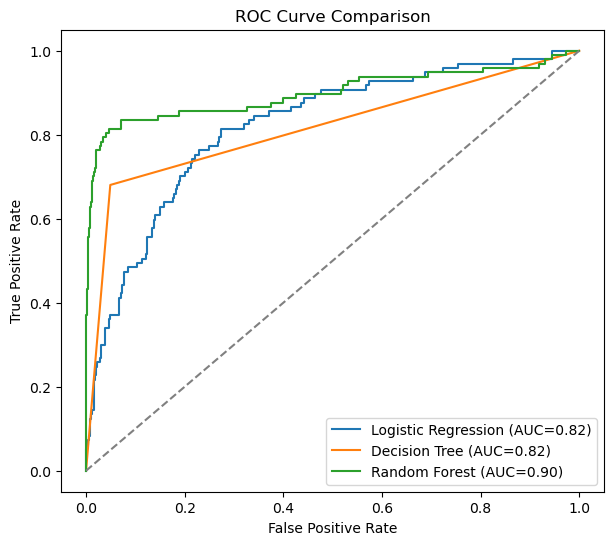

In [20]:
plt.figure(figsize=(7,6))

for model, name in [
    (logistic_pipeline, "Logistic Regression"),
    (tree_pipeline, "Decision Tree"),
    (randomforest_pipeline, "Random Forest")
]:
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_score = roc_auc_score(y_test, probs)

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.2f})")

plt.plot([0,1], [0,1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

#### 15.1 ROC Curve Comparison interpretation
The Random Forest model achieved the highest AUC score(**0.90**) indicating the strongest ability to separate churn customers from non-churn customers.

The Decision Tree model achieved higher recall for churn detection but Random Forest model provides the best overall classification performance due to its higher AUC and stability.This suggests that Random Forest captures more complex patterns in the data and generalizes better than the other models, model with a higher AUC provides more reliable predictions when identifying customers at risk of leaving.

### 16 .Model comparison Table

In [21]:
results_df = pd.DataFrame([logistic_results, tree_results, randomforest_results])
results_df.sort_values(by="Recall", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,Decision Tree,0.911544,0.702128,0.680412,0.691099,0.815645
2,Random Forest,0.917541,0.956522,0.453608,0.615385,0.898173
0,Logistic Regression,0.865067,0.568627,0.298969,0.391892,0.819805


### Model Comparison Summary
- **Logistic Regression** simple and interpretable but has low recall.
- **Decision Tree** has the highest recall,it identifies more actual churners.
- **Random Forest** has the highest precision and ROC-AUC, it is more accurate when predicting churn.

Missing churn is costly for the business, recall is important but precision also reduces unnecessary retention efforts.Tuning of Random Forest is done to improve the model performance

### 17. Hyperparameter Tuning for Random Forest
Hyperparameter tuning is done to improve the models performance to identify customers who churn.GridSearchCV is used to tune the Random Forest model. The tuning process focuses on **recall** because in churn prediction correctly identifying customers who are likely to churn is important for the business.

In [22]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [5, 10, 15],
    "model__min_samples_split": [2, 5, 10]
}

In [23]:
grid_search = GridSearchCV(
    randomforest_pipeline,
    param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

In [24]:
grid_search.fit(X_train, y_train)
grid_search.best_params_

{'model__max_depth': 15,
 'model__min_samples_split': 5,
 'model__n_estimators': 300}

===== Tuned Random Forest =====

Classification Report
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       570
           1       0.97      0.59      0.73        97

    accuracy                           0.94       667
   macro avg       0.95      0.79      0.85       667
weighted avg       0.94      0.94      0.93       667



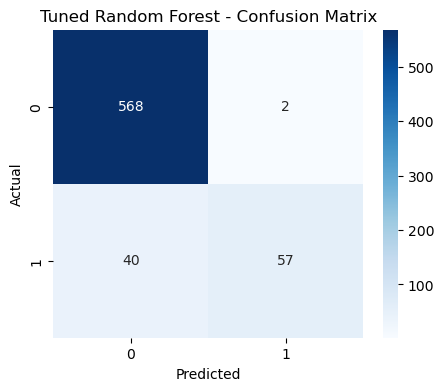

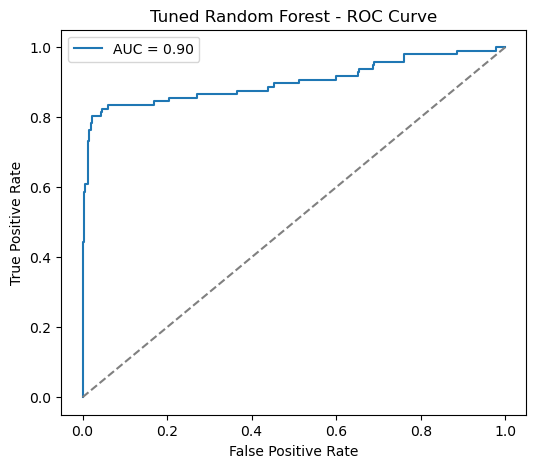

Tuned Random Forest AUC Score: 0.901


In [25]:
best_rf = grid_search.best_estimator_

tuned_rf_results = evaluate_model(
    best_rf, X_train, X_test, y_train, y_test, "Tuned Random Forest"
)

#### Tuned Random Forest interpretation

The tuned Random Forest improved recall to 0.59 compared to the untuned Random Forest 0.45 and maintaining a good precision.


#### 18. Updated Comparison Table

In [26]:
#Summarize all model results in a dataframe for comparison
results_df = pd.DataFrame([logistic_results, tree_results, randomforest_results, tuned_rf_results])
results_df.sort_values(by="Recall", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,Decision Tree,0.911544,0.702128,0.680412,0.691099,0.815645
3,Tuned Random Forest,0.937031,0.966102,0.587629,0.730769,0.901085
2,Random Forest,0.917541,0.956522,0.453608,0.615385,0.898173
0,Logistic Regression,0.865067,0.568627,0.298969,0.391892,0.819805


The Decision Tree still has a slightly higher recall, the tuned Random Forest offered the best overall balance between identifying churners and minimizing false positives.It has the highest accuracy,precision,F1 Score,ROC AUC,the recall improved meaningfully compared to the untuned Random Forest.This makes it the most practical model for targeted customer retention efforts.

### 19. Feature Importance
The feature importance results show that the most influential predictors in the final model 


In [27]:
# Fit the tuned Random Forest
best_rf.fit(X_train, y_train)

# Apply feature engineering transformation
X_train_fe = best_rf.named_steps["features"].transform(X_train)

# Get feature names after preprocessing
feature_names = best_rf.named_steps["preprocess"].get_feature_names_out(X_train_fe.columns)

# Extract trained Random Forest model
rf_model = best_rf.named_steps["model"]

# Create feature importance dataframe
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Show top 20 features
importance_df.head(10)

,Feature,Importance
3,numerical_scaling__total day minutes,0.158759
12,numerical_scaling__total_minutes,0.138834
14,numerical_scaling__service_call_rate,0.082614
11,numerical_scaling__customer service calls,0.075439
66,categorical_encoding__international plan_yes,0.068390
15,numerical_scaling__day_usage_ratio,0.054126
5,numerical_scaling__total eve minutes,0.048967
9,numerical_scaling__total intl minutes,0.043300
10,numerical_scaling__total intl calls,0.036868
7,numerical_scaling__total night minutes,0.034004


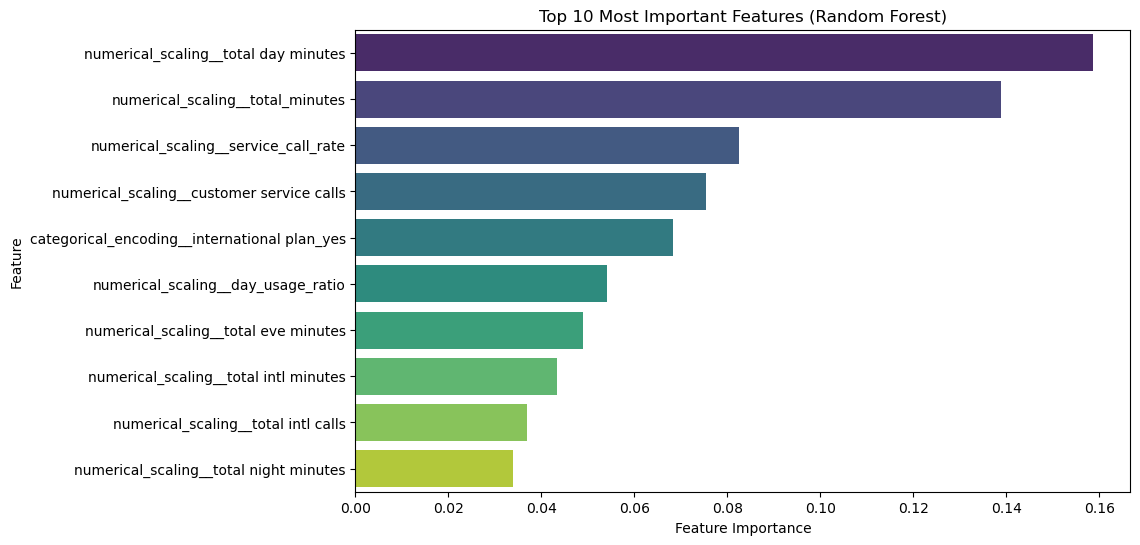

In [28]:
#Plot feature importance
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature",
    palette= sns.color_palette("viridis", n_colors=10)
)

plt.title("Top 10 Most Important Features (Random Forest)")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

### Feature Importance
The top 10 features influencing customers churn are:
- total day minutes
- total minutes
- service call rate
- customer service calls
- international plan
- day usage ratio
- total evening minutes
- total international minutes
- total international calls
- total night minutes

These results suggest that churn is strongly influenced by:
1. **Customer usage behavior**
2. **Interaction with customer service**
3. **Service plan characteristics**

In particular, high day usage and a high rate of customer service calls appear to be strong indicators of churn risk.

### 20. Business Findings

The analysis shows that customer churn at SyriaTel is associated with both customer behavior and customer service experience indicators.

Key findings:
- The dataset is imbalanced, with churn representing only **14.5%** of customers.
- Customers who make more customer service calls are more likely to churn.
- Customers with higher day-minute usage also appear more likely to churn.
- Usage-related variables and service interaction variables are among the most important predictors in the final model.
- The Tuned Random Forest provided the best overall balance of predictive performance, with strong precision, improved recall, and the highest ROC-AUC.

These findings suggest that churn is not random. It can be anticipated using patterns in service usage and customer support behavior.

### 21. Recommendations

Based on the findings, SyriaTel should consider the following actions:

1. **Monitor frequent customer service callers**
   - Customers who contact customer service repeatedly should be noted for proactive follow-up, since they are more likely to churn.

2. **Target high day-usage customers**
   - Customers with high daytime usage may benefit from personalized plans, loyalty discounts, or service upgrades to reduce churn risk.

3. **Review international plan customers**
   - Since international plan features were important in the model, SyriaTel should assess whether these customers are receiving competitive value and service quality.

4. **Use the churn model for targeted retention campaigns**
   - Instead of applying retention actions broadly, SyriaTel can use the model to focus on customers with the highest predicted churn risk.

5. **Test intervention effectiveness**
   - SyriaTel should track whether retention actions actually reduce churn among the high-risk customers identified by the model.

6. **Improve the model further in future work**
   - Future improvements could include threshold tuning, class weighting, or additional models

Although the Decision Tree achieved the highest recall, the Tuned Random Forest was selected as the final model because it provided the best overall balance between identifying churners and minimizing false predictions. This makes it the most practical model for supporting targeted customer retention at SyriaTel.